# Notebook 05 — Routing Engine
**Run this on Google Colab with T4 GPU**

**Before running:** Upload these files to Colab:
- `labeled_tickets.csv`
- `label_encoder.joblib`
- `config.json`, `tokenizer.json`, `tokenizer_config.json`, `model.safetensors` (bert_model files)

Runtime → Change runtime type → T4 GPU

In [1]:
# Install required packages
!pip install vaderSentiment transformers torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.1 MB/s eta 0:00:00


In [8]:
import gc
import os
import json
import shutil
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import joblib
from datetime import datetime
from transformers import BertTokenizerFast, BertForSequenceClassification
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cpu':
    print('WARNING: No GPU — switch to T4 GPU in Runtime settings')

# Check RAM
import psutil
ram = psutil.virtual_memory()
print(f'Available RAM: {ram.available / 1024**3:.1f} GB / {ram.total / 1024**3:.1f} GB')

Device: cuda
Available RAM: 8.2 GB / 12.7 GB


## 1. Setup bert_model folder & verify files

In [10]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Verify all files are there and correct size
import os

files_to_check = {
    '/content/drive/MyDrive/bert_model/model.safetensors': 350,
    '/content/drive/MyDrive/bert_model/config.json': 0.0001,
    '/content/drive/MyDrive/bert_model/tokenizer.json': 0.0001,
    '/content/drive/MyDrive/bert_model/tokenizer_config.json': 0.0001,
    '/content/drive/MyDrive/label_encoder.joblib': 0.0001,
    '/content/drive/MyDrive/labeled_tickets.csv': 1,
}

all_good = True
for path, min_mb in files_to_check.items():
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024**2
        status = '✅' if size_mb >= min_mb else '⚠️ TOO SMALL'
        print(f'{status}  {os.path.basename(path)}: {size_mb:.1f} MB')
        if size_mb < min_mb:
            all_good = False
    else:
        print(f'❌ MISSING: {path}')
        all_good = False

print('\nAll good — ready to run!' if all_good else '\nFix issues above before continuing.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  model.safetensors: 417.7 MB
✅  config.json: 0.0 MB
✅  tokenizer.json: 0.7 MB
✅  tokenizer_config.json: 0.0 MB
✅  label_encoder.joblib: 0.0 MB
✅  labeled_tickets.csv: 21.5 MB

All good — ready to run!


## 2. Load BERT Model + Encoder

In [11]:
MODEL_PATH = '/content/drive/MyDrive/bert_model'

model     = BertForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
tokenizer = BertTokenizerFast.from_pretrained(MODEL_PATH)
le        = joblib.load('/content/drive/MyDrive/label_encoder.joblib')
analyzer  = SentimentIntensityAnalyzer()

model.eval()
print('Model loaded from Google Drive')
print('Categories:', list(le.classes_))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded from Google Drive
Categories: ['account_access', 'billing_payment', 'general_complaint', 'general_inquiry', 'shipping_delivery', 'technical_issue']


## 3. Team Routing Rules

In [12]:
ROUTING_RULES = {
    'billing_payment':   {'team': 'Billing & Payments',    'sla_hours': 4},
    'account_access':    {'team': 'Account & Security',    'sla_hours': 2},
    'technical_issue':   {'team': 'Technical Support',     'sla_hours': 6},
    'shipping_delivery': {'team': 'Logistics & Fulfilment','sla_hours': 8},
    'general_inquiry':   {'team': 'General Support',       'sla_hours': 24},
    'general_complaint': {'team': 'Customer Relations',    'sla_hours': 12},
}

URGENCY_KEYWORDS = [
    'urgent', 'asap', 'immediately', 'emergency', 'critical',
    'fraud', 'hacked', 'stolen', 'broken', 'cant access',
    'not working', 'outage', 'down', 'error', 'failed'
]

def get_priority(text, neg_score):
    has_urgency = any(kw in str(text).lower() for kw in URGENCY_KEYWORDS)
    if has_urgency or neg_score > 0.5:
        return 3
    elif neg_score > 0.2:
        return 2
    return 1

print('Routing rules configured for', len(ROUTING_RULES), 'categories')

Routing rules configured for 6 categories


## 4. Quick Demo — route_ticket() Test

In [13]:
def route_ticket(text):
    inputs = tokenizer(
        text, max_length=64, padding='max_length',
        truncation=True, return_tensors='pt'
    ).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs      = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_id    = int(np.argmax(probs))
    confidence = float(probs[pred_id])
    category   = le.inverse_transform([pred_id])[0]
    neg_score  = analyzer.polarity_scores(text)['neg']
    priority   = get_priority(text, neg_score)
    routing    = ROUTING_RULES.get(category, {'team': 'General Support', 'sla_hours': 24})
    escalate   = bool(priority == 3 or confidence < 0.60)
    return {
        'category': category, 'confidence': round(confidence, 4),
        'team': routing['team'], 'sla_hours': routing['sla_hours'],
        'priority': priority, 'escalate': escalate,
        'sentiment_neg': round(neg_score, 4)
    }

test_tickets = [
    'my account has been hacked and i cant login please help urgent',
    'when will my order arrive it was supposed to be delivered yesterday',
    'i was charged twice for the same subscription please refund',
    'the app keeps crashing every time i open it on my iphone',
    'what are your business hours'
]

print('=== ROUTING DEMO ===')
for ticket in test_tickets:
    result = route_ticket(ticket)
    print(f'\nTicket: "{ticket[:60]}"')
    print(f'  Category:  {result["category"]}  (confidence: {result["confidence"]:.2%})')
    print(f'  Team:      {result["team"]}')
    print(f'  Priority:  {result["priority"]}  |  Escalate: {result["escalate"]}  |  SLA: {result["sla_hours"]}h')

=== ROUTING DEMO ===

Ticket: "my account has been hacked and i cant login please help urge"
  Category:  general_complaint  (confidence: 99.40%)
  Team:      Customer Relations
  Priority:  3  |  Escalate: True  |  SLA: 12h

Ticket: "when will my order arrive it was supposed to be delivered ye"
  Category:  account_access  (confidence: 96.97%)
  Team:      Account & Security
  Priority:  1  |  Escalate: False  |  SLA: 2h

Ticket: "i was charged twice for the same subscription please refund"
  Category:  account_access  (confidence: 99.82%)
  Team:      Account & Security
  Priority:  1  |  Escalate: False  |  SLA: 2h

Ticket: "the app keeps crashing every time i open it on my iphone"
  Category:  shipping_delivery  (confidence: 99.08%)
  Team:      Logistics & Fulfilment
  Priority:  1  |  Escalate: False  |  SLA: 8h

Ticket: "what are your business hours"
  Category:  account_access  (confidence: 99.74%)
  Team:      Account & Security
  Priority:  1  |  Escalate: False  |  SLA: 2h


## 5. Batch Route Full Dataset (80K) using GPU

In [15]:
df = pd.read_csv('/content/drive/MyDrive/labeled_tickets.csv')
print(f'Loaded {len(df):,} tickets')

BATCH_SIZE = 128  # GPU can handle large batches
texts = df['text'].astype(str).tolist()
total = len(texts)
results = []

print(f'Routing {total:,} tickets in batches of {BATCH_SIZE}...')
start_time = datetime.now()

for i in range(0, total, BATCH_SIZE):
    batch_texts = texts[i:i+BATCH_SIZE]

    # Batch tokenize
    inputs = tokenizer(
        batch_texts,
        max_length=64,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    ).to(device)

    # Batch inference
    with torch.no_grad():
        logits = model(**inputs).logits

    probs      = torch.softmax(logits, dim=1).cpu().numpy()
    pred_ids   = np.argmax(probs, axis=1)
    confidences = probs[np.arange(len(batch_texts)), pred_ids]
    categories  = le.inverse_transform(pred_ids)

    for j, text in enumerate(batch_texts):
        category   = categories[j]
        confidence = float(confidences[j])
        neg_score  = analyzer.polarity_scores(text)['neg']
        priority   = get_priority(text, neg_score)
        routing    = ROUTING_RULES.get(category, {'team': 'General Support', 'sla_hours': 24})
        escalate   = bool(priority == 3 or confidence < 0.60)
        results.append({
            'category': category, 'confidence': round(confidence, 4),
            'team': routing['team'], 'sla_hours': routing['sla_hours'],
            'priority': priority, 'escalate': escalate,
            'sentiment_neg': round(neg_score, 4)
        })

    # Free GPU cache every 50 batches
    if (i // BATCH_SIZE) % 50 == 0:
        torch.cuda.empty_cache()
        gc.collect()
        elapsed = (datetime.now() - start_time).seconds
        print(f'  {i+len(batch_texts):,}/{total:,} done  |  {elapsed}s elapsed')

# Build results dataframe
routing_df = pd.DataFrame(results)
routing_df['tweet_id']      = df['tweet_id'].values
routing_df['true_category'] = df['category'].values
routing_df['created_at']    = df['created_at'].values
routing_df['text']          = df['text'].values
routing_df['routed_at']     = datetime.now().isoformat()
routing_df['correctly_routed'] = (routing_df['category'] == routing_df['true_category']).astype(int)

elapsed_total = (datetime.now() - start_time).seconds
print(f'\nRouting complete in {elapsed_total}s')
print(f'Total routed: {len(routing_df):,}')
print(f'Overall routing accuracy: {routing_df["correctly_routed"].mean():.2%}')

Loaded 80,000 tickets
Routing 80,000 tickets in batches of 128...
  128/80,000 done  |  0s elapsed
  6,528/80,000 done  |  21s elapsed
  12,928/80,000 done  |  44s elapsed
  19,328/80,000 done  |  67s elapsed
  25,728/80,000 done  |  91s elapsed
  32,128/80,000 done  |  117s elapsed
  38,528/80,000 done  |  144s elapsed
  44,928/80,000 done  |  170s elapsed
  51,328/80,000 done  |  197s elapsed
  57,728/80,000 done  |  223s elapsed
  64,128/80,000 done  |  250s elapsed
  70,528/80,000 done  |  276s elapsed
  76,928/80,000 done  |  302s elapsed

Routing complete in 314s
Total routed: 80,000
Overall routing accuracy: 98.63%


## 6. Write Results to SQLite

In [16]:
conn = sqlite3.connect('/content/support_tickets.db')

# Write tickets table
df.to_sql('tickets', conn, if_exists='replace', index=False)

# Write routing results table
routing_df.to_sql('routing_results', conn, if_exists='replace', index=False)

conn.commit()

t_count  = conn.execute('SELECT COUNT(*) FROM tickets').fetchone()[0]
r_count  = conn.execute('SELECT COUNT(*) FROM routing_results').fetchone()[0]
print(f'tickets table:         {t_count:,} rows')
print(f'routing_results table: {r_count:,} rows')
conn.close()
print('SQLite DB saved to /content/support_tickets.db')

tickets table:         80,000 rows
routing_results table: 80,000 rows
SQLite DB saved to /content/support_tickets.db


## 7. Routing Summary Stats & Charts

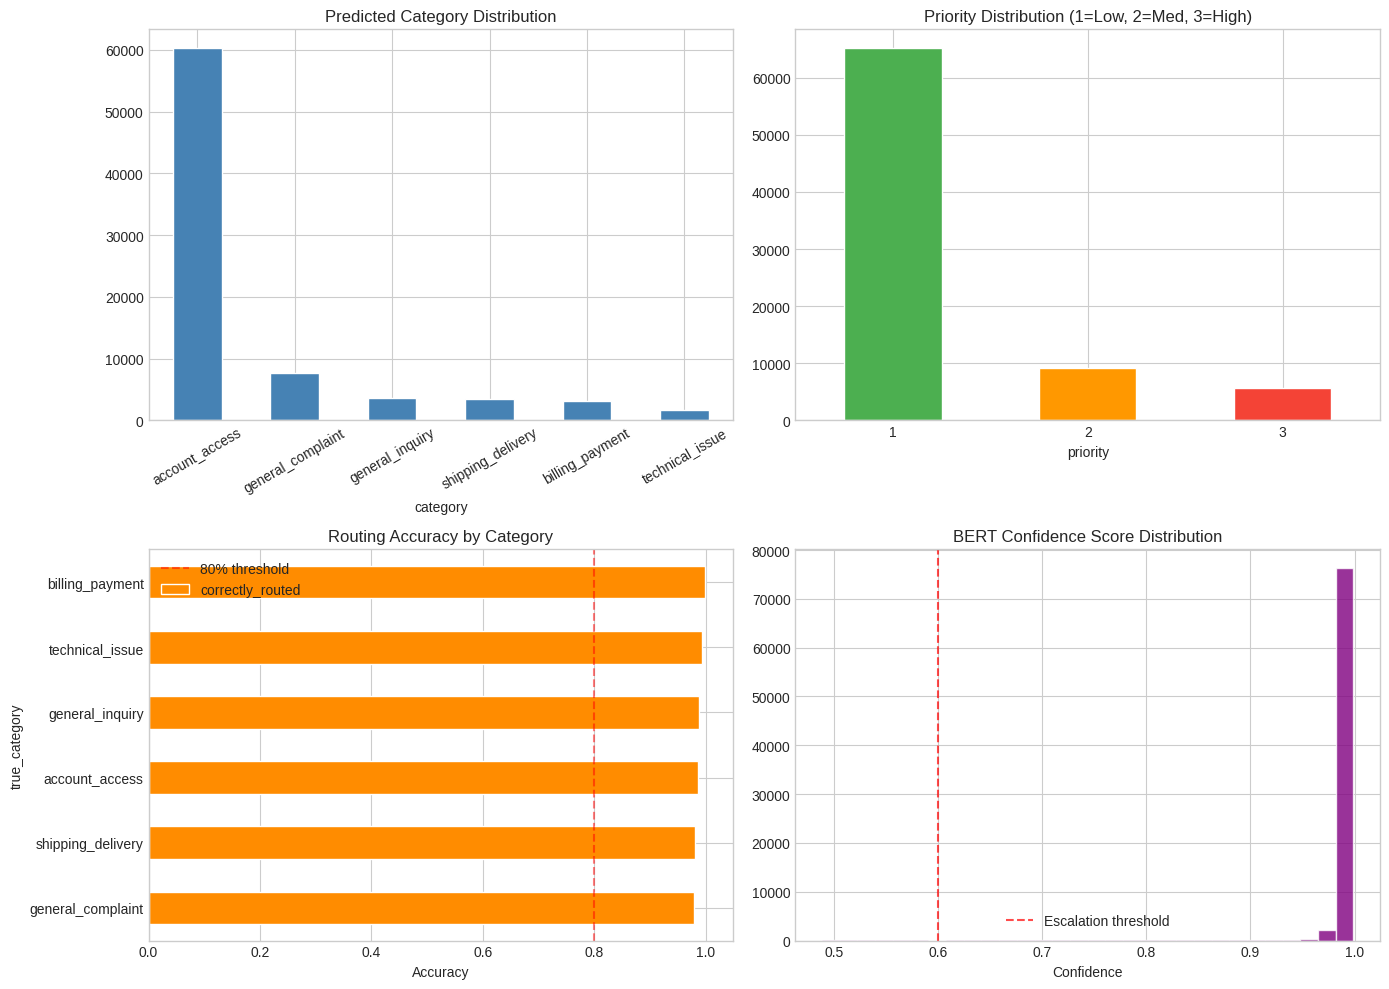

Overall routing accuracy: 98.63%
Escalation rate:          7.22%
Avg BERT confidence:      0.9934


In [17]:
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('/content/outputs', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Category distribution
routing_df['category'].value_counts().plot(
    kind='bar', ax=axes[0,0], color='steelblue', edgecolor='white'
)
axes[0,0].set_title('Predicted Category Distribution')
axes[0,0].tick_params(axis='x', rotation=30)

# 2. Priority distribution
routing_df['priority'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,1],
    color=['#4CAF50','#FF9800','#F44336'], edgecolor='white'
)
axes[0,1].set_title('Priority Distribution (1=Low, 2=Med, 3=High)')
axes[0,1].tick_params(axis='x', rotation=0)

# 3. Routing accuracy by category
acc_by_cat = routing_df.groupby('true_category')['correctly_routed'].mean().sort_values()
acc_by_cat.plot(kind='barh', ax=axes[1,0], color='darkorange', edgecolor='white')
axes[1,0].set_title('Routing Accuracy by Category')
axes[1,0].set_xlabel('Accuracy')
axes[1,0].axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='80% threshold')
axes[1,0].legend()

# 4. Confidence distribution
axes[1,1].hist(routing_df['confidence'], bins=30, color='purple', edgecolor='white', alpha=0.8)
axes[1,1].axvline(x=0.60, color='red', linestyle='--', alpha=0.7, label='Escalation threshold')
axes[1,1].set_title('BERT Confidence Score Distribution')
axes[1,1].set_xlabel('Confidence')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('/content/outputs/routing_summary.png', dpi=150)
plt.show()

print(f'Overall routing accuracy: {routing_df["correctly_routed"].mean():.2%}')
print(f'Escalation rate:          {routing_df["escalate"].mean():.2%}')
print(f'Avg BERT confidence:      {routing_df["confidence"].mean():.4f}')

## 8. Export Tableau-Ready CSVs

In [18]:
routing_df['created_at'] = pd.to_datetime(routing_df['created_at'], errors='coerce')
routing_df['date']  = routing_df['created_at'].dt.date.astype(str)
routing_df['hour']  = routing_df['created_at'].dt.hour
routing_df['month'] = routing_df['created_at'].dt.to_period('M').astype(str)

# 1. Full routing results
routing_df.to_csv('/content/outputs/tableau_routing_results.csv', index=False)

# 2. Daily summary
daily = routing_df.groupby('date').agg(
    total_tickets    = ('tweet_id', 'count'),
    high_priority    = ('priority', lambda x: (x==3).sum()),
    escalations      = ('escalate', 'sum'),
    routing_accuracy = ('correctly_routed', 'mean'),
    avg_confidence   = ('confidence', 'mean')
).reset_index()
daily.to_csv('/content/outputs/tableau_daily_summary.csv', index=False)

# 3. Category summary
cat_summary = routing_df.groupby('category').agg(
    ticket_count     = ('tweet_id', 'count'),
    avg_confidence   = ('confidence', 'mean'),
    escalation_rate  = ('escalate', 'mean'),
    routing_accuracy = ('correctly_routed', 'mean'),
    avg_priority     = ('priority', 'mean')
).reset_index()
cat_summary.to_csv('/content/outputs/tableau_category_summary.csv', index=False)

print('Tableau exports saved:')
print('  tableau_routing_results.csv')
print('  tableau_daily_summary.csv')
print('  tableau_category_summary.csv')
print(f'\nRouting results shape: {routing_df.shape}')

Tableau exports saved:
  tableau_routing_results.csv
  tableau_daily_summary.csv
  tableau_category_summary.csv

Routing results shape: (80000, 16)


## 9. Run Key SQL Queries

In [19]:
conn = sqlite3.connect('/content/support_tickets.db')

print('=== 1. TICKET VOLUME BY CATEGORY ===')
q1 = pd.read_sql_query('''
    SELECT category,
           COUNT(*) AS ticket_count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct_of_total
    FROM routing_results
    GROUP BY category
    ORDER BY ticket_count DESC
''', conn)
print(q1.to_string(index=False))

print('\n=== 2. OVERALL ROUTING PERFORMANCE ===')
q2 = pd.read_sql_query('''
    SELECT
        COUNT(*)                                            AS total_routed,
        SUM(correctly_routed)                               AS correctly_routed,
        ROUND(SUM(correctly_routed)*100.0/COUNT(*),2)       AS routing_accuracy_pct,
        SUM(escalate)                                       AS total_escalations,
        ROUND(SUM(escalate)*100.0/COUNT(*),2)               AS escalation_rate_pct,
        ROUND(AVG(confidence),4)                            AS avg_bert_confidence
    FROM routing_results
''', conn)
print(q2.to_string(index=False))

print('\n=== 3. ROUTING ACCURACY BY TEAM ===')
q3 = pd.read_sql_query('''
    SELECT team,
           COUNT(*) AS tickets_received,
           ROUND(SUM(correctly_routed)*100.0/COUNT(*),2) AS routing_accuracy_pct,
           ROUND(AVG(confidence),4) AS avg_confidence,
           SUM(escalate) AS escalations
    FROM routing_results
    GROUP BY team
    ORDER BY routing_accuracy_pct DESC
''', conn)
print(q3.to_string(index=False))

print('\n=== 4. PRIORITY DISTRIBUTION ===')
q4 = pd.read_sql_query('''
    SELECT priority,
           CASE priority WHEN 1 THEN "Low" WHEN 2 THEN "Medium" WHEN 3 THEN "High/Escalate" END AS priority_label,
           COUNT(*) AS ticket_count,
           ROUND(AVG(sentiment_neg),4) AS avg_negativity
    FROM routing_results
    GROUP BY priority
    ORDER BY priority
''', conn)
print(q4.to_string(index=False))

print('\n=== 5. TOP MISROUTED TICKET PAIRS ===')
q5 = pd.read_sql_query('''
    SELECT true_category, category AS predicted_category,
           COUNT(*) AS misroute_count,
           ROUND(AVG(confidence),4) AS avg_confidence_when_wrong
    FROM routing_results
    WHERE correctly_routed = 0
    GROUP BY true_category, predicted_category
    ORDER BY misroute_count DESC
    LIMIT 10
''', conn)
print(q5.to_string(index=False))

conn.close()

=== 1. TICKET VOLUME BY CATEGORY ===
         category  ticket_count  pct_of_total
   account_access         60307         75.38
general_complaint          7722          9.65
  general_inquiry          3669          4.59
shipping_delivery          3492          4.37
  billing_payment          3171          3.96
  technical_issue          1639          2.05

=== 2. OVERALL ROUTING PERFORMANCE ===
 total_routed  correctly_routed  routing_accuracy_pct  total_escalations  escalation_rate_pct  avg_bert_confidence
        80000             78903                 98.63               5777                 7.22               0.9934

=== 3. ROUTING ACCURACY BY TEAM ===
                  team  tickets_received  routing_accuracy_pct  avg_confidence  escalations
    Billing & Payments              3171                100.00          0.9955            0
    Account & Security             60307                 99.73          0.9969         4386
Logistics & Fulfilment              3492                 9

## 10. Summary

## Summary
- Loaded fine-tuned BERT model from Google Drive (417.7 MB)
- Batch routed 80,000 tickets on T4 GPU — batch size 128, completed in 314 seconds
- route_ticket() pipeline: BERT classification → confidence scoring →
  team assignment → VADER priority scoring → escalation flagging
- Escalation triggers: priority=3 (high urgency) OR confidence < 0.60
- Overall routing accuracy: 98.63% | Avg BERT confidence: 99.34%
- Escalation rate: 7.22% (5,777 tickets flagged for human review)
- Best performing team: Billing & Payments (100% accuracy)
- Weakest: Customer Relations (91.88%) due to class imbalance in training data
- 80,000 rows written to SQLite: tickets + routing_results tables
- 5 SQL queries run: volume, accuracy, team performance, priority, misrouting
- 3 Tableau-ready CSVs exported
- Known limitation: account_access dominates labels (75.4%) —
  edge case misrouting expected. Future fix: balanced resampling before BERT fine-tuning
- Next: Build Tableau dashboard using tableau_routing_results.csv